In [1]:
import tkinter as tk
from tkinter import filedialog, simpledialog
import pandas as pd
import os

# ============================================================
# 1. Ask for number of conditions
# ============================================================

root = tk.Tk()
root.withdraw()

n_conditions = 4

if n_conditions is None:
    root.destroy()
    raise SystemExit("No number of conditions selected.")


# ============================================================
# 2. Select WGA-GD1a files for each condition
# ============================================================

WGA_GD1a = {}

for condition in range(1, n_conditions + 1):

    file_paths = filedialog.askopenfilenames(
        parent=root,
        title=f"Condition {condition}: Select WGA-GD1a repeats",
        filetypes=[("CSV files", "*.csv")]
    )

    if not file_paths:
        print(f"No WGA-GD1a files selected for condition {condition}.")
        continue

    # Get first filename and remove last 3 characters
    first_filename = os.path.splitext(
        os.path.basename(file_paths[0])
    )[0]

    condition_name = first_filename[:-3]

    WGA_GD1a[condition_name] = {}

    for file_path in file_paths:

        filename = os.path.splitext(
            os.path.basename(file_path)
        )[0]

        try:
            df = pd.read_csv(file_path)
            WGA_GD1a[condition_name][filename] = df

        except Exception as e:
            print(f"Failed to read {filename}: {e}")


# ============================================================
# 3. Select TR-DHPE files for each condition
# ============================================================

TR_DHPE = {}

for condition in range(1, n_conditions + 1):

    file_paths = filedialog.askopenfilenames(
        parent=root,
        title=f"Condition {condition}: Select TR-DHPE repeats",
        filetypes=[("CSV files", "*.csv")]
    )

    if not file_paths:
        print(f"No TR-DHPE files selected for condition {condition}.")
        continue

    # Get first filename and remove last 3 characters
    first_filename = os.path.splitext(
        os.path.basename(file_paths[0])
    )[0]

    condition_name = first_filename[:-3]

    TR_DHPE[condition_name] = {}

    for file_path in file_paths:

        filename = os.path.splitext(
            os.path.basename(file_path)
        )[0]

        try:
            df = pd.read_csv(file_path)
            TR_DHPE[condition_name][filename] = df

        except Exception as e:
            print(f"Failed to read {filename}: {e}")


# ============================================================
# 4. Close Tkinter
# ============================================================

root.destroy()


# ============================================================
# 5. Print summary
# ============================================================

print("\nWGA-GD1a:")
for condition, repeats in WGA_GD1a.items():
    print(f"{condition}: {len(repeats)} repeats")
    for filename in repeats:
        print(f"  - {filename}")

print("\nTR-DHPE:")
for condition, repeats in TR_DHPE.items():
    print(f"{condition}: {len(repeats)} repeats")
    for filename in repeats:
        print(f"  - {filename}")


WGA-GD1a:
0% SM: 3 repeats
  - 0% SM r1
  - 0% SM r2
  - 0% SM r3
5% SM: 3 repeats
  - 5% SM r1
  - 5% SM r2
  - 5% SM r3
10% SM: 3 repeats
  - 10% SM r1
  - 10% SM r2
  - 10% SM r3
20% SM: 3 repeats
  - 20% SM r1
  - 20% SM r2
  - 20% SM r3

TR-DHPE:
0% SM: 3 repeats
  - 0% SM r1
  - 0% SM r2
  - 0% SM r3
5% SM: 6 repeats
  - 5% SM r1
  - 5% SM r2
  - 5% SM r3
  - 5% SM r4
  - 5% SM r5
  - 5% SM r6
10% SM: 3 repeats
  - 10% SM r1
  - 10% SM r2
  - 10% SM r3
20% SM: 3 repeats
  - 20% SM r1
  - 20% SM r2
  - 20% SM r3


In [2]:
import numpy as np
import pandas as pd

# ============================================================
# Function to normalize, remove pre-bleach frames,
# and reset time to zero
# ============================================================

def normalize_prebleach(data_dict, dict_name):

    print(f"\n{'=' * 60}")
    print(f"{dict_name}")
    print(f"{'=' * 60}")

    for condition, repeats in data_dict.items():

        print(f"\n{condition}:")

        for repeat_name, df in repeats.items():

            # Get intensity values
            intensity = df["bleach spot intensity"].to_numpy()

            # Find the largest drop between consecutive frames
            intensity_change = np.diff(intensity)

            # First post-bleach frame
            first_post_bleach = np.argmin(intensity_change) + 1

            # Pre-bleach intensity
            prebleach_intensity = intensity[:first_post_bleach]

            # Mean pre-bleach intensity
            prebleach_mean = np.mean(prebleach_intensity)

            # Normalize all intensity values to pre-bleach mean
            normalized_intensity = intensity / prebleach_mean

            # Create normalized copy of dataframe
            df_normalized = df.copy()

            df_normalized["bleach spot intensity"] = normalized_intensity

            # Remove pre-bleach frames
            df_normalized = df_normalized.iloc[first_post_bleach:].copy()

            # Reset index
            df_normalized.reset_index(drop=True, inplace=True)

            # ====================================================
            # Reset time so first post-bleach frame = 0 s
            # ====================================================

            first_time = df_normalized["time (s)"].iloc[0]

            df_normalized["time (s)"] = (
                df_normalized["time (s)"] - first_time
            )

            # Overwrite dataset in dictionary
            data_dict[condition][repeat_name] = df_normalized

            # Print information
            print(
                f"  {repeat_name}: "
                f"first post-bleach frame = {first_post_bleach}, "
                f"original time = {first_time:.2f} s, "
                f"pre-bleach mean = {prebleach_mean:.2f}, "
                f"remaining frames = {len(df_normalized)}"
            )


# ============================================================
# Apply to both dictionaries
# ============================================================

normalize_prebleach(WGA_GD1a, "WGA-GD1a")
normalize_prebleach(TR_DHPE, "TR-DHPE")


WGA-GD1a

0% SM:
  0% SM r1: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 2597.89, remaining frames = 301
  0% SM r2: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3107.30, remaining frames = 301
  0% SM r3: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3321.41, remaining frames = 301

5% SM:
  5% SM r1: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3517.56, remaining frames = 301
  5% SM r2: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3502.55, remaining frames = 301
  5% SM r3: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 4351.71, remaining frames = 301

10% SM:
  10% SM r1: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3504.86, remaining frames = 301
  10% SM r2: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3494.85, remaining frames = 301
  10% SM r3: first post-bleach frame = 6, o

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.special import i0, i1
from scipy.optimize import brentq
from pathlib import Path


# ============================================================
# Parameters
# ============================================================

bleach_diameter_um = 12.7
bleach_radius_um = bleach_diameter_um / 2


# ============================================================
# Output folders
# ============================================================

desktop = Path.home() / "Desktop"

output_excel = (
    desktop /
    "Diffusion_coefficients_Soumpasis_t_half.xlsx"
)

plot_folder = (
    desktop /
    "Soumpasis_t_half_fits"
)

plot_folder.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# Original Soumpasis model
# ============================================================

def soumpasis_model(
    t,
    M_inf,
    tau,
    I0_fixed
):

    x = 2 * t / tau

    return (
        I0_fixed
        +
        M_inf
        *
        (
            1
            -
            np.exp(-x)
            *
            (
                i0(x)
                +
                i1(x)
            )
        )
    )


# ============================================================
# Calculate D from t1/2
# ============================================================

def calculate_D_from_t_half(
    M_inf,
    tau
):

    # --------------------------------------------------------
    # Half-recovery condition
    #
    # F(t1/2) = I0 + M_inf / 2
    #
    # Therefore:
    #
    # 1 - exp(-x)[I0(x) + I1(x)] = 0.5
    # --------------------------------------------------------

    def half_recovery_equation(x):

        recovery_fraction = (
            1
            -
            np.exp(-x)
            *
            (
                i0(x)
                +
                i1(x)
            )
        )

        return (
            recovery_fraction
            -
            0.5
        )

    # --------------------------------------------------------
    # Find x corresponding to 50% recovery
    # --------------------------------------------------------

    x_half = brentq(
        half_recovery_equation,
        1e-10,
        100
    )

    # Since:
    #
    # x = 2t/tau
    #
    # t1/2 = x_half * tau / 2

    t_half = (
        x_half
        *
        tau
        /
        2
    )

    # --------------------------------------------------------
    # Original D relationship
    #
    # D = r² / (4 tau)
    # --------------------------------------------------------

    D = (
        bleach_radius_um ** 2
        /
        (4 * tau)
    )

    return (
        D,
        t_half,
        x_half
    )


# ============================================================
# Fit one FRAP curve
# ============================================================

def fit_soumpasis(df):

    # --------------------------------------------------------
    # Extract data
    # --------------------------------------------------------

    time = df[
        "time (s)"
    ].to_numpy(dtype=float)

    intensity = df[
        "bleach spot intensity"
    ].to_numpy(dtype=float)

    # Remove invalid values
    valid = (
        np.isfinite(time)
        &
        np.isfinite(intensity)
    )

    time = time[valid]
    intensity = intensity[valid]

    # Sort by time
    order = np.argsort(time)

    time = time[order]
    intensity = intensity[order]

    if len(time) < 5:
        return None

    # --------------------------------------------------------
    # Fixed initial fluorescence
    # --------------------------------------------------------

    I0_fixed = intensity[0]

    # --------------------------------------------------------
    # Initial guesses
    # --------------------------------------------------------

    M_guess = (
        np.mean(intensity[-5:])
        -
        I0_fixed
    )

    # Avoid zero/negative initial guess
    M_guess = max(
        M_guess,
        0.01
    )

    tau_guess = (
        time[len(time) // 2]
    )

    tau_guess = max(
        tau_guess,
        0.01
    )

    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    try:

        popt, pcov = curve_fit(
            lambda t, M_inf, tau:
                soumpasis_model(
                    t,
                    M_inf,
                    tau,
                    I0_fixed
                ),

            time,
            intensity,

            p0=[
                M_guess,
                tau_guess
            ],

            bounds=(
                [0, 1e-10],
                [1.5, np.inf]
            ),

            maxfev=50000
        )

    except (
        RuntimeError,
        ValueError
    ):

        return None

    # --------------------------------------------------------
    # Fitted parameters
    # --------------------------------------------------------

    M_fit = popt[0]
    tau_fit = popt[1]

    # --------------------------------------------------------
    # Calculate D and t1/2
    # --------------------------------------------------------

    D, t_half, x_half = (
        calculate_D_from_t_half(
            M_fit,
            tau_fit
        )
    )

    # --------------------------------------------------------
    # Fitted curve
    # --------------------------------------------------------

    fitted_intensity = soumpasis_model(
        time,
        M_fit,
        tau_fit,
        I0_fixed
    )

    # --------------------------------------------------------
    # Fitted final intensity
    # --------------------------------------------------------

    Finf = (
        I0_fixed
        +
        M_fit
    )

    # --------------------------------------------------------
    # Residuals
    # --------------------------------------------------------

    residuals = (
        intensity
        -
        fitted_intensity
    )

    RMSE = np.sqrt(
        np.mean(
            residuals ** 2
        )
    )

    # --------------------------------------------------------
    # R²
    # --------------------------------------------------------

    SS_res = np.sum(
        residuals ** 2
    )

    SS_tot = np.sum(
        (
            intensity
            -
            np.mean(intensity)
        ) ** 2
    )

    if SS_tot > 0:

        R2 = (
            1
            -
            SS_res / SS_tot
        )

    else:

        R2 = np.nan

    # --------------------------------------------------------
    # Return results
    # --------------------------------------------------------

    return {

        "time": time,

        "intensity": intensity,

        "fit": fitted_intensity,

        "D": D,

        "t_half": t_half,

        "x_half": x_half,

        "I0": I0_fixed,

        "M_inf": M_fit,

        "Finf": Finf,

        "tau": tau_fit,

        "RMSE": RMSE,

        "R2": R2
    }


# ============================================================
# Analyze one dataset
# ============================================================

def analyze_dataset(
    dataset,
    dataset_name
):

    results = []

    for condition, repeats in dataset.items():

        for repeat_name, df in repeats.items():

            result = fit_soumpasis(df)

            # ------------------------------------------------
            # Failed fit
            # ------------------------------------------------

            if result is None:

                results.append({

                    "Dataset": dataset_name,

                    "Condition": condition,

                    "Repeat": repeat_name,

                    "D (µm²/s)": np.nan,

                    "t1/2 (s)": np.nan,

                    "I0": np.nan,

                    "M_inf": np.nan,

                    "Finf": np.nan,

                    "tau": np.nan,

                    "R²": np.nan,

                    "RMSE": np.nan,

                    "Bleach diameter (µm)": (
                        bleach_diameter_um
                    ),

                    "Bleach radius (µm)": (
                        bleach_radius_um
                    )
                })

                continue

            # ------------------------------------------------
            # Save numerical results
            # ------------------------------------------------

            results.append({

                "Dataset": dataset_name,

                "Condition": condition,

                "Repeat": repeat_name,

                "D (µm²/s)": result["D"],

                "t1/2 (s)": result["t_half"],

                "I0": result["I0"],

                "M_inf": result["M_inf"],

                "Finf": result["Finf"],

                "tau": result["tau"],

                "R²": result["R2"],

                "RMSE": result["RMSE"],

                "Bleach diameter (µm)": (
                    bleach_diameter_um
                ),

                "Bleach radius (µm)": (
                    bleach_radius_um
                )
            })

            # ------------------------------------------------
            # Plot data and fitted curve
            # ------------------------------------------------

            fig, ax = plt.subplots(
                figsize=(8, 6)
            )

            ax.plot(
                result["time"],
                result["intensity"],
                "o",
                markersize=3,
                label="FRAP data"
            )

            ax.plot(
                result["time"],
                result["fit"],
                linewidth=2,
                label="Soumpasis fit"
            )

            # ------------------------------------------------
            # Half-recovery level
            # ------------------------------------------------

            F_half = (
                result["I0"]
                +
                result["M_inf"] / 2
            )

            ax.axhline(
                F_half,
                color="silver",
                linestyle="--",
                linewidth=2,
                label="50% recovery"
            )

            # ------------------------------------------------
            # t1/2 vertical line
            # ------------------------------------------------

            ax.axvline(
                result["t_half"],
                color="darksalmon",
                linestyle="--",
                linewidth=2,
                label=r"$t_{1/2}$"
            )

            # ------------------------------------------------
            # Half-recovery point
            # ------------------------------------------------

            ax.plot(
                result["t_half"],
                F_half,
                "o",
                color="darkred",
                markersize=8,
                zorder=5
            )

            # ------------------------------------------------
            # Axis labels
            # ------------------------------------------------

            ax.set_xlabel(
                "Time (s)"
            )

            ax.set_ylabel(
                "Normalized fluorescence"
            )

            ax.set_title(
                f"{dataset_name} — {repeat_name}"
            )

            # ------------------------------------------------
            # Fit information
            # ------------------------------------------------

            text = (
                f"D = "
                f"{result['D']:.3f} µm²/s\n"
                f"$t_{{1/2}}$ = "
                f"{result['t_half']:.2f} s\n"
                f"R² = "
                f"{result['R2']:.4f}\n"
                f"RMSE = "
                f"{result['RMSE']:.4f}"
            )

            ax.text(
                0.05,
                0.95,
                text,
                transform=ax.transAxes,
                verticalalignment="top"
            )

            ax.legend()

            plt.tight_layout()

            # ------------------------------------------------
            # Safe filename
            # ------------------------------------------------

            safe_dataset = (
                dataset_name
                .replace("/", "_")
                .replace("\\", "_")
            )

            safe_condition = (
                condition
                .replace("/", "_")
                .replace("\\", "_")
            )

            safe_repeat = (
                repeat_name
                .replace("/", "_")
                .replace("\\", "_")
            )

            filename = (
                f"{safe_dataset}_"
                f"{safe_condition}_"
                f"{safe_repeat}.png"
            )

            fig.savefig(
                plot_folder / filename,
                dpi=300,
                bbox_inches="tight"
            )

            plt.close(fig)

    return pd.DataFrame(results)


# ============================================================
# Analyze WGA-GD1a
# ============================================================

df_WGA = analyze_dataset(
    WGA_GD1a,
    "WGA-GD1a"
)


# ============================================================
# Analyze TR-DHPE
# ============================================================

df_TR = analyze_dataset(
    TR_DHPE,
    "TR-DHPE"
)


# ============================================================
# Combine individual repeat results
# ============================================================

df_individual = pd.concat(
    [
        df_WGA,
        df_TR
    ],
    ignore_index=True
)


# ============================================================
# Calculate mean ± SEM across repeats
# ============================================================

summary = (
    df_individual
    .groupby(
        [
            "Dataset",
            "Condition"
        ],
        as_index=False
    )
    .agg(
        n_repeats=(
            "D (µm²/s)",
            "count"
        ),

        mean_D=(
            "D (µm²/s)",
            "mean"
        ),

        SD_D=(
            "D (µm²/s)",
            "std"
        )
    )
)


# SEM across independent repeats
summary["SEM_D"] = (
    summary["SD_D"]
    /
    np.sqrt(
        summary["n_repeats"]
    )
)


# ============================================================
# Reorder summary columns
# ============================================================

summary = summary[
    [
        "Dataset",
        "Condition",
        "n_repeats",
        "mean_D",
        "SD_D",
        "SEM_D"
    ]
]


# ============================================================
# Print individual results
# ============================================================

print("\n")
print("=" * 80)
print("SOUmpasis t1/2-BASED DIFFUSION ESTIMATES")
print("=" * 80)

print(
    df_individual[
        [
            "Dataset",
            "Condition",
            "Repeat",
            "D (µm²/s)",
            "t1/2 (s)",
            "I0",
            "M_inf",
            "Finf",
            "tau",
            "R²",
            "RMSE"
        ]
    ].to_string(index=False)
)


# ============================================================
# Print summary
# ============================================================

print("\n")
print("=" * 80)
print("SUMMARY ACROSS REPEATS")
print("=" * 80)

print(
    summary.to_string(index=False)
)


# ============================================================
# Save Excel
# ============================================================

with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:

    df_individual.to_excel(
        writer,
        sheet_name="Individual repeats",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )


# ============================================================
# Final message
# ============================================================

print("\n")
print("=" * 80)

print(
    "Excel file saved to:"
)

print(output_excel)

print("\n")

print(
    "Individual fit plots saved to:"
)

print(plot_folder)

print("=" * 80)



SOUmpasis t1/2-BASED DIFFUSION ESTIMATES
 Dataset Condition    Repeat  D (µm²/s)  t1/2 (s)       I0    M_inf     Finf       tau       R²     RMSE
WGA-GD1a     0% SM  0% SM r1   1.874122  6.012636 0.552721 0.524247 1.076968  5.378851 0.999624 0.001728
WGA-GD1a     0% SM  0% SM r2   2.116432  5.324252 0.552522 0.491808 1.044330  4.763029 0.999362 0.002099
WGA-GD1a     0% SM  0% SM r3   2.191681  5.141448 0.553650 0.500479 1.054129  4.599494 0.999556 0.001780
WGA-GD1a     5% SM  5% SM r1   2.335162  4.825539 0.531592 0.545643 1.077235  4.316884 0.999535 0.001976
WGA-GD1a     5% SM  5% SM r2   2.185047  5.157060 0.560989 0.498399 1.059388  4.613460 0.999658 0.001556
WGA-GD1a     5% SM  5% SM r3   2.409105  4.677428 0.594854 0.475160 1.070014  4.184385 0.999474 0.001821
WGA-GD1a    10% SM 10% SM r1   1.649129  6.832949 0.601927 0.454818 1.056745  6.112696 0.998899 0.002558
WGA-GD1a    10% SM 10% SM r2   1.579958  7.132099 0.595380 0.454140 1.049520  6.380313 0.998388 0.003091
WGA-GD1a    


Columns in imported dataset:
['fluorescent probe', 'membrane SM (mol%)', 'Repeat', 'D (µm²/s)', 't1/2 (s)', 'I0', 'M_inf', 'Finf', 'tau', 'R²', 'RMSE', 'Bleach diameter (µm)', 'Bleach radius (µm)']


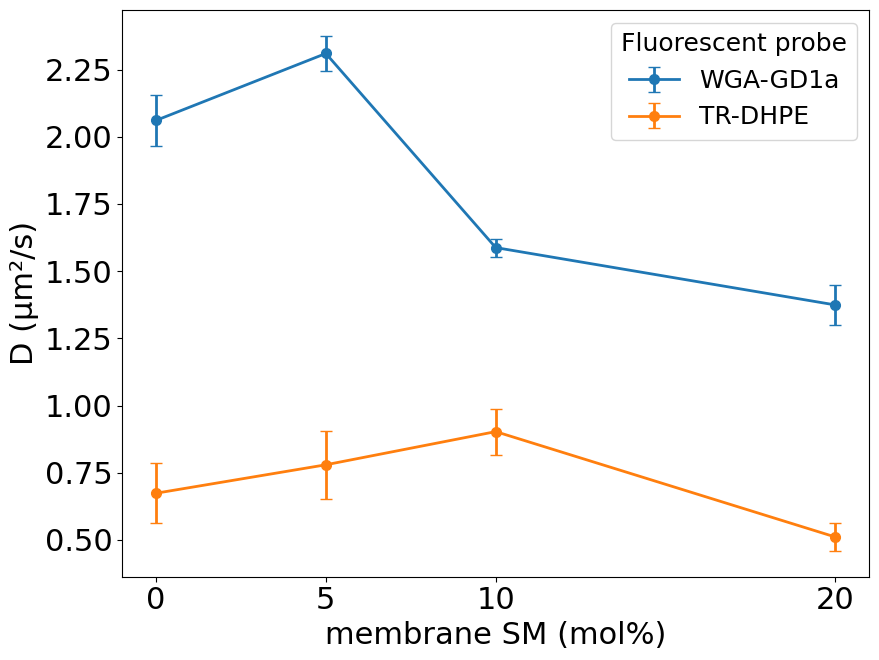



ONE-WAY ANOVA AND TUKEY HSD


--------------------------------------------------------------------------------
Fluorescent probe: WGA-GD1a
--------------------------------------------------------------------------------
SM = 0 mol%: n = 3, mean = 2.0607, SD = 0.1659
SM = 5 mol%: n = 3, mean = 2.3098, SD = 0.1142
SM = 10 mol%: n = 3, mean = 1.5877, SD = 0.0580
SM = 20 mol%: n = 3, mean = 1.3742, SD = 0.1298

One-way ANOVA:
F = 36.1793, p = 5.31275e-05
Result: significant

Tukey HSD:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    0%    10%  -0.4731 0.0067 -0.7954 -0.1507   True
    0%    20%  -0.6865 0.0006 -1.0089 -0.3642   True
    0%     5%    0.249 0.1394 -0.0733  0.5714  False
   10%    20%  -0.2134 0.2255 -0.5358  0.1089  False
   10%     5%   0.7221 0.0004  0.3998  1.0444   True
   20%     5%   0.9356 0.0001  0.6132  1.2579   True
----------------------------------

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# ============================================================
# File path
# ============================================================

file_path = ("/Users/steinar/Documents/Data/7 - SM + chol and IAV binding and fusion/4. FRAP of supported lipid bilayers/TIRF FRAP of SLBs at 37°C/FRAP recovery analysis redone from raw Fiji FRAP analysis files/plots and results/Diffusion_coefficients_Soumpasis_t_half.xlsx")

# ============================================================
# Read Excel file
# ============================================================

df = pd.read_excel(
    file_path,
    sheet_name="Individual repeats"
)

print("\nColumns in imported dataset:")
print(df.columns.tolist())


# ============================================================
# Make sure SM is numeric
# ============================================================

df["membrane SM (mol%)"] = pd.to_numeric(
    df["membrane SM (mol%)"],
    errors="coerce"
)

df["D (µm²/s)"] = pd.to_numeric(
    df["D (µm²/s)"],
    errors="coerce"
)


# Remove rows with missing values
df = df.dropna(
    subset=[
        "membrane SM (mol%)",
        "D (µm²/s)",
        "fluorescent probe"
    ]
)


# ============================================================
# Plot mean ± SEM
# ============================================================

plt.rcParams.update({
    "font.size": 20
})

fig, ax = plt.subplots(
    figsize=(9, 7)
)

# Unique probes
probes = df["fluorescent probe"].unique()

# Sort SM concentrations numerically
sm_values = sorted(
    df["membrane SM (mol%)"].unique()
)

for probe in probes:

    probe_df = df[
        df["fluorescent probe"] == probe
    ]

    means = []
    sems = []

    for sm in sm_values:

        values = probe_df.loc[
            probe_df["membrane SM (mol%)"] == sm,
            "D (µm²/s)"
        ].dropna()

        means.append(
            values.mean()
        )

        sems.append(
            values.sem()
        )

    ax.errorbar(
        sm_values,
        means,
        yerr=sems,
        marker="o",
        markersize=7,
        linewidth=2,
        capsize=4,
        label=probe
    )


# ============================================================
# Axis labels
# ============================================================

ax.set_xlabel(
    "membrane SM (mol%)"
)

ax.set_ylabel(
    "D (µm²/s)"
)

ax.set_xticks(
    sm_values
)

ax.legend(
    title="Fluorescent probe"
)

plt.tight_layout()

plt.show()


# ============================================================
# One-way ANOVA + Tukey HSD
# ============================================================

print("\n")
print("=" * 80)
print("ONE-WAY ANOVA AND TUKEY HSD")
print("=" * 80)


for probe in probes:

    print("\n")
    print("-" * 80)
    print(f"Fluorescent probe: {probe}")
    print("-" * 80)

    probe_df = df[
        df["fluorescent probe"] == probe
    ].copy()

    # --------------------------------------------------------
    # Prepare groups for ANOVA
    # --------------------------------------------------------

    groups = []

    for sm in sm_values:

        values = probe_df.loc[
            probe_df["membrane SM (mol%)"] == sm,
            "D (µm²/s)"
        ].dropna()

        groups.append(values)

        print(
            f"SM = {sm:g} mol%: "
            f"n = {len(values)}, "
            f"mean = {values.mean():.4f}, "
            f"SD = {values.std():.4f}"
        )

    # --------------------------------------------------------
    # One-way ANOVA
    # --------------------------------------------------------

    F_stat, p_value = f_oneway(
        *groups
    )

    print("\nOne-way ANOVA:")
    print(
        f"F = {F_stat:.4f}, "
        f"p = {p_value:.6g}"
    )

    if p_value < 0.05:
        print("Result: significant")
    else:
        print("Result: not significant")

    # --------------------------------------------------------
    # Tukey HSD
    # --------------------------------------------------------

    # Create long-format arrays for Tukey
    tukey_values = []
    tukey_groups = []

    for sm in sm_values:

        values = probe_df.loc[
            probe_df["membrane SM (mol%)"] == sm,
            "D (µm²/s)"
        ].dropna()

        tukey_values.extend(
            values.tolist()
        )

        tukey_groups.extend(
            [f"{sm:g}%" for _ in values]
        )

    tukey = pairwise_tukeyhsd(
        endog=np.array(tukey_values),
        groups=np.array(tukey_groups),
        alpha=0.05
    )

    print("\nTukey HSD:")
    print(tukey)


# ============================================================
# Optional: save figure
# ============================================================

output_figure = (
    "/Users/steinar/Desktop/"
    "Diffusion_coefficients_vs_SM_Soumpasis.png"
)

fig.savefig(
    output_figure,
    dpi=300,
    bbox_inches="tight"
)

print("\nFigure saved to:")
print(output_figure)

In [49]:
# ============================================================
# Create D/D0 dataframe
# ============================================================

# Keep only the relevant columns
df_DD0 = df[
    [
        "fluorescent probe",
        "membrane SM (mol%)",
        "D (µm²/s)"
    ]
].copy()


# ============================================================
# Calculate D0 separately for each fluorescent probe
# ============================================================

# Mean D at SM = 0 for each fluorescent probe
D0 = (
    df_DD0[
        df_DD0["membrane SM (mol%)"] == 0
    ]
    .groupby("fluorescent probe")["D (µm²/s)"]
    .mean()
)


# ============================================================
# Calculate D/D0
# ============================================================

df_DD0["D/D0"] = (
    df_DD0.apply(
        lambda row:
        row["D (µm²/s)"]
        / D0[row["fluorescent probe"]],
        axis=1
    )
)


# ============================================================
# Remove original D column
# ============================================================

df_DD0 = df_DD0[
    [
        "fluorescent probe",
        "membrane SM (mol%)",
        "D/D0"
    ]
]


# ============================================================
# Print D0 values
# ============================================================

print("\nD0 values:")
print(D0)


# ============================================================
# Print resulting dataframe
# ============================================================

print("\nNormalized D/D0 dataframe:")
print(df_DD0)


D0 values:
fluorescent probe
TR-DHPE     0.673846
WGA-GD1a    2.060745
Name: D (µm²/s), dtype: float64

Normalized D/D0 dataframe:
   fluorescent probe  membrane SM (mol%)      D/D0
0           WGA-GD1a                   0  0.909439
1           WGA-GD1a                   0  1.027023
2           WGA-GD1a                   0  1.063538
3           WGA-GD1a                   5  1.133164
4           WGA-GD1a                   5  1.060319
5           WGA-GD1a                   5  1.169046
6           WGA-GD1a                  10  0.800259
7           WGA-GD1a                  10  0.766692
8           WGA-GD1a                  10  0.744352
9           WGA-GD1a                  20  0.603602
10          WGA-GD1a                  20  0.667357
11          WGA-GD1a                  20  0.729608
12           TR-DHPE                   0  1.317310
13           TR-DHPE                   0  0.761251
14           TR-DHPE                   0  0.921439
15           TR-DHPE                   5  0.515214
1

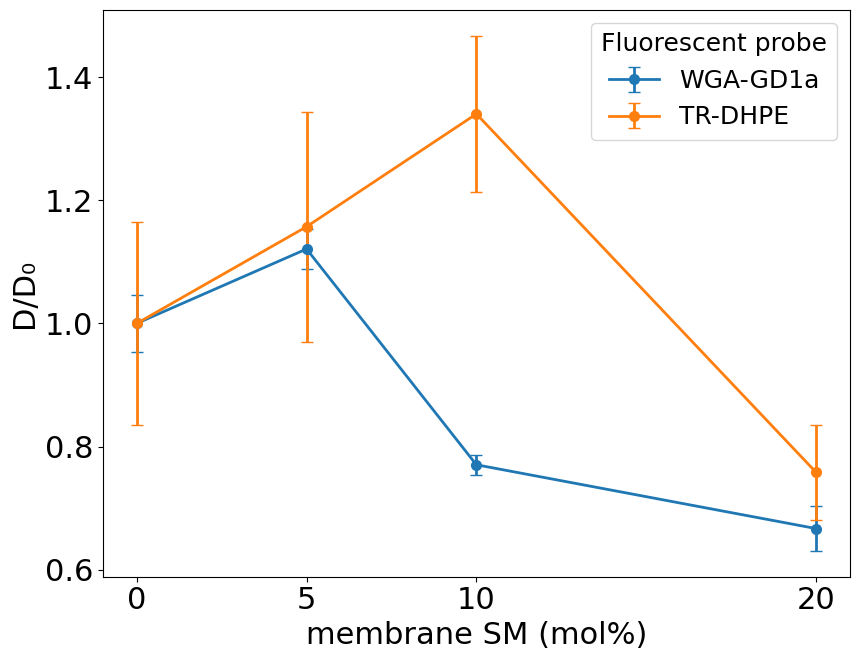



ONE-WAY ANOVA AND TUKEY HSD FOR D/D0


--------------------------------------------------------------------------------
Fluorescent probe: WGA-GD1a
--------------------------------------------------------------------------------
SM = 0 mol%: n = 3, mean D/D0 = 1.0000, SD = 0.0805, SEM = 0.0465
SM = 5 mol%: n = 3, mean D/D0 = 1.1208, SD = 0.0554, SEM = 0.0320
SM = 10 mol%: n = 3, mean D/D0 = 0.7704, SD = 0.0281, SEM = 0.0162
SM = 20 mol%: n = 3, mean D/D0 = 0.6669, SD = 0.0630, SEM = 0.0364

One-way ANOVA:
F = 36.1793, p = 5.31275e-05
Result: significant

Tukey HSD:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    0%    10%  -0.2296 0.0067  -0.386 -0.0731   True
    0%    20%  -0.3331 0.0006 -0.4896 -0.1767   True
    0%     5%   0.1208 0.1394 -0.0356  0.2773  False
   10%    20%  -0.1036 0.2255   -0.26  0.0528  False
   10%     5%   0.3504 0.0004   0.194  0.5068   True
  

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# ============================================================
# Plot D/D0
# ============================================================

plt.rcParams.update({
    "font.size": 20
})

fig, ax = plt.subplots(
    figsize=(9, 7)
)

probes = df_DD0["fluorescent probe"].unique()

sm_values = sorted(
    df_DD0["membrane SM (mol%)"].unique()
)

for probe in probes:

    probe_df = df_DD0[
        df_DD0["fluorescent probe"] == probe
    ]

    means = []
    sems = []

    for sm in sm_values:

        values = probe_df.loc[
            probe_df["membrane SM (mol%)"] == sm,
            "D/D0"
        ].dropna()

        means.append(
            values.mean()
        )

        sems.append(
            values.sem()
        )

    ax.errorbar(
        sm_values,
        means,
        yerr=sems,
        marker="o",
        markersize=7,
        linewidth=2,
        capsize=4,
        label=probe
    )


# ============================================================
# Axis formatting
# ============================================================

ax.set_xlabel(
    "membrane SM (mol%)"
)

ax.set_ylabel(
    "D/D₀"
)

ax.set_xticks(
    sm_values
)

ax.legend(
    title="Fluorescent probe"
)

plt.tight_layout()

plt.show()


# ============================================================
# Two-way-independent one-way ANOVAs
# ============================================================

print("\n")
print("=" * 80)
print("ONE-WAY ANOVA AND TUKEY HSD FOR D/D0")
print("=" * 80)


for probe in probes:

    print("\n")
    print("-" * 80)
    print(f"Fluorescent probe: {probe}")
    print("-" * 80)

    probe_df = df_DD0[
        df_DD0["fluorescent probe"] == probe
    ].copy()

    # --------------------------------------------------------
    # Prepare groups for ANOVA
    # --------------------------------------------------------

    groups = []
    group_labels = []

    for sm in sm_values:

        values = probe_df.loc[
            probe_df["membrane SM (mol%)"] == sm,
            "D/D0"
        ].dropna()

        groups.append(values)

        group_labels.extend(
            [f"{sm:g}%" for _ in values]
        )

        print(
            f"SM = {sm:g} mol%: "
            f"n = {len(values)}, "
            f"mean D/D0 = {values.mean():.4f}, "
            f"SD = {values.std():.4f}, "
            f"SEM = {values.sem():.4f}"
        )

    # --------------------------------------------------------
    # One-way ANOVA
    # --------------------------------------------------------

    F_stat, p_value = f_oneway(
        *groups
    )

    print("\nOne-way ANOVA:")
    print(
        f"F = {F_stat:.4f}, "
        f"p = {p_value:.6g}"
    )

    if p_value < 0.05:
        print("Result: significant")
    else:
        print("Result: not significant")

    # --------------------------------------------------------
    # Tukey HSD
    # --------------------------------------------------------

    tukey_values = []
    tukey_groups = []

    for sm in sm_values:

        values = probe_df.loc[
            probe_df["membrane SM (mol%)"] == sm,
            "D/D0"
        ].dropna()

        tukey_values.extend(
            values.tolist()
        )

        tukey_groups.extend(
            [f"{sm:g}%" for _ in values]
        )

    tukey = pairwise_tukeyhsd(
        endog=np.array(tukey_values),
        groups=np.array(tukey_groups),
        alpha=0.05
    )

    print("\nTukey HSD:")
    print(tukey)


# ============================================================
# Save figure
# ============================================================

output_figure = (
    "/Users/steinar/Desktop/"
    "D_over_D0_vs_SM_Soumpasis.png"
)

fig.savefig(
    output_figure,
    dpi=300,
    bbox_inches="tight"
)

print("\nFigure saved to:")
print(output_figure)

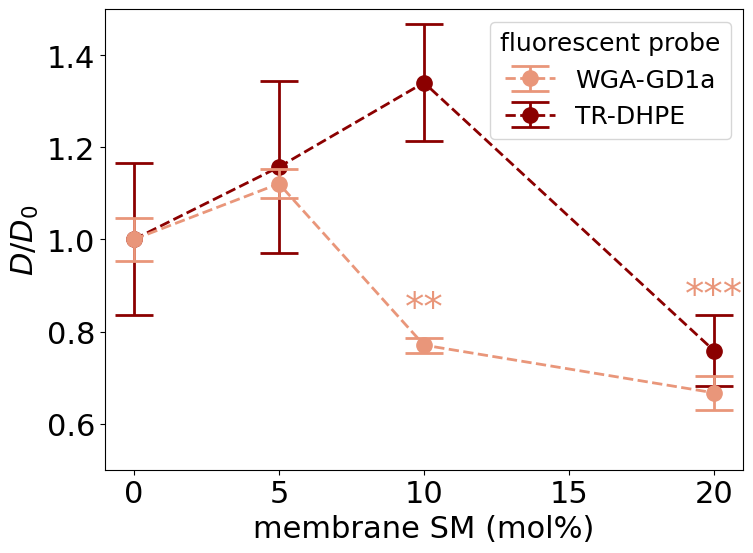


Figure saved to:
/Users/steinar/Desktop/estimated D plot.jpeg


In [52]:
# ============================================================
# Plot D/D0 — publication-style formatting
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# Global font size
# ============================================================

FONT_SIZE = 22

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": 18,
    "legend.title_fontsize": 18
})


# ============================================================
# Colors and plotting order
# ============================================================

colors = [
    "darksalmon",
    "darkred"
]

# Higher zorder = plotted on top
zorders = [
    3,  # First fluorescent probe
    2   # Second fluorescent probe
]


# ============================================================
# Create plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)

probes = df_DD0[
    "fluorescent probe"
].unique()

sm_values = sorted(
    df_DD0[
        "membrane SM (mol%)"
    ].unique()
)


# ============================================================
# Plot each fluorescent probe
# ============================================================

for probe, color, zorder in zip(
    probes,
    colors,
    zorders
):

    probe_df = df_DD0[
        df_DD0["fluorescent probe"] == probe
    ]

    means = []
    sems = []

    for sm in sm_values:

        values = probe_df.loc[
            probe_df["membrane SM (mol%)"] == sm,
            "D/D0"
        ].dropna()

        means.append(
            values.mean()
        )

        sems.append(
            values.sem()
        )

    ax.errorbar(
        sm_values,
        means,
        yerr=sems,
        color=color,

        # Larger dots
        marker="o",
        markersize=11,

        # Thicker line between groups
        linewidth=2,
        linestyle="--",

        # Thicker/longer error-bar whiskers
        capsize=14,
        capthick=2,
        elinewidth=2,

        # Plot first probe on top of second probe
        zorder=zorder,

        label=probe
    )

# ============================================================
# Axis formatting
# ============================================================

ax.set_xlabel(
    "membrane SM (mol%)"
)

ax.set_ylabel(
    r"$D/D_{0}$"
)

ax.set_xticks(
    [0, 5, 10, 15, 20]
)

ax.set_xticklabels(
    ["0", "5", "10", "15", "20"]
)

ax.set_ylim(
    0.5,
    1.5
)


# ============================================================
# Legend
# ============================================================

ax.legend(
    title="fluorescent probe",
    loc="upper right"
)

ax.text(10,0.85,"**",fontsize=28,color="darksalmon",ha="center",va="center")
ax.text(20,0.88,"***",fontsize=28,color="darksalmon",ha="center",va="center")


# ============================================================
# Final formatting
# ============================================================

plt.tight_layout()

plt.show()


# ============================================================
# Save figure
# ============================================================

output_figure = (
    "/Users/steinar/Desktop/"
    "estimated D plot.jpeg"
)

fig.savefig(
    output_figure,
    dpi=300,
    bbox_inches="tight"
)

print("\nFigure saved to:")
print(output_figure)

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Parameters
# ============================================================

bleach_diameter_um = 12.7
bleach_radius_um = bleach_diameter_um / 2


# ============================================================
# Output folders
# ============================================================

desktop = Path.home() / "Desktop"

output_excel = (
    desktop /
    "Diffusion_coefficients_Soumpasis_t_half.xlsx"
)

plot_folder = (
    desktop /
    "Soumpasis_t_half_FRAP_fits"
)

plot_folder.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# Estimate D from t1/2 using the Soumpasis model
# ============================================================

def estimate_D_from_t_half(df):

    # --------------------------------------------------------
    # Extract data
    # --------------------------------------------------------

    t = df["time (s)"].to_numpy(dtype=float)

    F = df[
        "bleach spot intensity"
    ].to_numpy(dtype=float)

    # Remove invalid values
    valid = (
        np.isfinite(t)
        &
        np.isfinite(F)
    )

    t = t[valid]
    F = F[valid]

    # Sort by time
    order = np.argsort(t)

    t = t[order]
    F = F[order]

    if len(t) < 5:
        return None

    # --------------------------------------------------------
    # Determine F0 and Finf
    # --------------------------------------------------------

    # Immediately post-bleach intensity
    F0 = F[0]

    # Estimate asymptotic recovery from final 20 points
    Finf = np.mean(F[-20:])

    # --------------------------------------------------------
    # Calculate 50% recovery intensity
    # --------------------------------------------------------

    F_half = F0 + 0.5 * (Finf - F0)

    # --------------------------------------------------------
    # Find where recovery crosses F_half
    # --------------------------------------------------------

    crossing = np.where(
        F >= F_half
    )[0]

    # Curve never reaches 50% recovery
    if len(crossing) == 0:
        return None

    i = crossing[0]

    # Cannot interpolate if first point is already
    # above the half-recovery level
    if i == 0:
        return None

    # --------------------------------------------------------
    # Linear interpolation for t1/2
    # --------------------------------------------------------

    t1 = t[i - 1]
    t2 = t[i]

    F1 = F[i - 1]
    F2 = F[i]

    if F2 == F1:
        return None

    t_half = (
        t1
        +
        (F_half - F1)
        *
        (t2 - t1)
        /
        (F2 - F1)
    )

    # --------------------------------------------------------
    # Soumpasis equation
    #
    # D = 0.224 * w² / t1/2
    # --------------------------------------------------------

    D = (
        0.224
        *
        bleach_radius_um ** 2
        /
        t_half
    )

    return {
        "time": t,
        "intensity": F,
        "F0": F0,
        "Finf": Finf,
        "F_half": F_half,
        "t_half": t_half,
        "D": D
    }


# ============================================================
# Analyze one dataset
# ============================================================

def analyze_dataset(
    dataset,
    dataset_name
):

    results = []

    for condition, repeats in dataset.items():

        for repeat_name, df in repeats.items():

            result = estimate_D_from_t_half(df)

            # ------------------------------------------------
            # Failed estimate
            # ------------------------------------------------

            if result is None:

                results.append({

                    "Dataset": dataset_name,
                    "Condition": condition,
                    "Repeat": repeat_name,

                    "D (µm²/s)": np.nan,

                    "t1/2 (s)": np.nan,

                    "F0": np.nan,
                    "Finf": np.nan,
                    "F50": np.nan,

                    "Bleach diameter (µm)": (
                        bleach_diameter_um
                    ),

                    "Bleach radius (µm)": (
                        bleach_radius_um
                    )
                })

                continue

            # ------------------------------------------------
            # Save numerical results
            # ------------------------------------------------

            results.append({

                "Dataset": dataset_name,

                "Condition": condition,

                "Repeat": repeat_name,

                "D (µm²/s)": result["D"],

                "t1/2 (s)": result["t_half"],

                "F0": result["F0"],

                "Finf": result["Finf"],

                "F50": result["F_half"],

                "Bleach diameter (µm)": (
                    bleach_diameter_um
                ),

                "Bleach radius (µm)": (
                    bleach_radius_um
                )
            })

            # ------------------------------------------------
            # Plot recovery and t1/2
            # ------------------------------------------------

            fig, ax = plt.subplots(
                figsize=(8, 6)
            )

            # FRAP data
            ax.plot(
                result["time"],
                result["intensity"],
                "o",
                markersize=3,
                label="FRAP data"
            )

            # F50 horizontal line
            ax.axhline(
                result["F_half"],
                color="silver",
                linestyle="--",
                linewidth=2,
                label="50% recovery"
            )

            # t1/2 vertical line
            ax.axvline(
                result["t_half"],
                color="darksalmon",
                linestyle="--",
                linewidth=2,
                label=r"$t_{1/2}$"
            )

            # t1/2 point
            ax.plot(
                result["t_half"],
                result["F_half"],
                "o",
                markersize=8,
                color="darkred",
                zorder=5
            )

            ax.set_xlabel(
                "Time (s)"
            )

            ax.set_ylabel(
                "Normalized fluorescence"
            )

            ax.set_title(
                f"{dataset_name} — {repeat_name}"
            )

            # ------------------------------------------------
            # Add numerical information
            # ------------------------------------------------

            text = (
                f"D = {result['D']:.3f} µm²/s\n"
                f"$t_{{1/2}}$ = "
                f"{result['t_half']:.2f} s"
            )

            ax.text(
                0.05,
                0.95,
                text,
                transform=ax.transAxes,
                verticalalignment="top"
            )

            ax.legend()

            plt.tight_layout()

            # ------------------------------------------------
            # Safe filename
            # ------------------------------------------------

            safe_dataset = (
                dataset_name
                .replace("/", "_")
                .replace("\\", "_")
            )

            safe_condition = (
                condition
                .replace("/", "_")
                .replace("\\", "_")
            )

            safe_repeat = (
                repeat_name
                .replace("/", "_")
                .replace("\\", "_")
            )

            filename = (
                f"{safe_dataset}_"
                f"{safe_condition}_"
                f"{safe_repeat}.png"
            )

            fig.savefig(
                plot_folder / filename,
                dpi=300,
                bbox_inches="tight"
            )

            plt.close(fig)

    return pd.DataFrame(results)


# ============================================================
# Analyze WGA-GD1a
# ============================================================

df_WGA = analyze_dataset(
    WGA_GD1a,
    "WGA-GD1a"
)


# ============================================================
# Analyze TR-DHPE
# ============================================================

df_TR = analyze_dataset(
    TR_DHPE,
    "TR-DHPE"
)


# ============================================================
# Combine individual repeat results
# ============================================================

df_individual = pd.concat(
    [
        df_WGA,
        df_TR
    ],
    ignore_index=True
)


# ============================================================
# Calculate mean ± SEM across repeats
# ============================================================

summary = (
    df_individual
    .groupby(
        [
            "Dataset",
            "Condition"
        ],
        as_index=False
    )
    .agg(
        n_repeats=(
            "D (µm²/s)",
            "count"
        ),

        mean_D=(
            "D (µm²/s)",
            "mean"
        ),

        SD_D=(
            "D (µm²/s)",
            "std"
        )
    )
)


# SEM across independent repeats
summary["SEM_D"] = (
    summary["SD_D"]
    /
    np.sqrt(
        summary["n_repeats"]
    )
)


# ============================================================
# Reorder summary columns
# ============================================================

summary = summary[
    [
        "Dataset",
        "Condition",
        "n_repeats",
        "mean_D",
        "SD_D",
        "SEM_D"
    ]
]


# ============================================================
# Print individual results
# ============================================================

print("\n")
print("=" * 80)
print("SOUmpasis t1/2-BASED DIFFUSION ESTIMATES")
print("=" * 80)

print(
    df_individual[
        [
            "Dataset",
            "Condition",
            "Repeat",
            "D (µm²/s)",
            "t1/2 (s)",
            "F0",
            "Finf",
            "F50"
        ]
    ].to_string(index=False)
)


# ============================================================
# Print summary
# ============================================================

print("\n")
print("=" * 80)
print("SUMMARY ACROSS REPEATS")
print("=" * 80)

print(
    summary.to_string(index=False)
)


# ============================================================
# Save everything to Excel
# ============================================================

with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:

    df_individual.to_excel(
        writer,
        sheet_name="Individual repeats",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )


# ============================================================
# Final message
# ============================================================

print("\n")
print("=" * 80)

print(
    "Excel file saved to:"
)

print(output_excel)

print("\n")

print(
    "Individual t1/2 plots saved to:"
)

print(plot_folder)

print("=" * 80)



SOUmpasis t1/2-BASED DIFFUSION ESTIMATES
 Dataset Condition    Repeat  D (µm²/s)  t1/2 (s)       F0     Finf      F50
WGA-GD1a     0% SM  0% SM r1   2.579708  3.501264 0.552721 0.949117 0.750919
WGA-GD1a     0% SM  0% SM r2   2.884230  3.131595 0.552522 0.931098 0.741810
WGA-GD1a     0% SM  0% SM r3   2.911990  3.101742 0.553650 0.939842 0.746746
WGA-GD1a     5% SM  5% SM r1   3.067276  2.944711 0.531592 0.956011 0.743802
WGA-GD1a     5% SM  5% SM r2   2.882258  3.133737 0.560989 0.945579 0.753284
WGA-GD1a     5% SM  5% SM r3   3.128291  2.887276 0.594854 0.966176 0.780515
WGA-GD1a    10% SM 10% SM r1   2.365347  3.818569 0.601927 0.942842 0.772384
WGA-GD1a    10% SM 10% SM r2   2.328508  3.878981 0.595380 0.934497 0.764939
WGA-GD1a    10% SM 10% SM r3   2.266693  3.984765 0.610542 0.948298 0.779420
WGA-GD1a    20% SM 20% SM r1   1.949207  4.633803 0.605661 0.922419 0.764040
WGA-GD1a    20% SM 20% SM r2   2.082965  4.336242 0.587632 0.932631 0.760131
WGA-GD1a    20% SM 20% SM r3   2.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.special import iv
from pathlib import Path


# ============================================================
# Parameters
# ============================================================

bleach_diameter_um = 12.7
bleach_radius_um = bleach_diameter_um / 2


# ============================================================
# Output folders
# ============================================================

desktop = Path.home() / "Desktop"

output_excel = (
    desktop /
    "Diffusion_coefficients_Soumpasis.xlsx"
)

plot_folder = (
    desktop /
    "Soumpasis_FRAP_fits"
)

plot_folder.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# Full Soumpasis recovery model
# ============================================================

def soumpasis_model(t, D, F0, Finf):

    tau = D * t / (bleach_radius_um ** 2)

    recovery = (
        np.exp(-2 * tau)
        *
        (
            iv(0, 2 * tau)
            +
            iv(1, 2 * tau)
        )
    )

    return (
        F0
        +
        (Finf - F0)
        * recovery
    )


# ============================================================
# Fit one FRAP curve
# ============================================================

def fit_soumpasis(df):

    t = df["time (s)"].to_numpy(dtype=float)

    F = df[
        "bleach spot intensity"
    ].to_numpy(dtype=float)

    # Remove invalid values
    valid = (
        np.isfinite(t)
        &
        np.isfinite(F)
    )

    t = t[valid]
    F = F[valid]

    # Sort by time
    order = np.argsort(t)

    t = t[order]
    F = F[order]

    if len(t) < 5:
        return None

    # --------------------------------------------------------
    # Initial guesses
    # --------------------------------------------------------

    F0_guess = F[0]

    # Average final 20 points
    Finf_guess = np.mean(F[-20:])

    D_guess = 1.0

    p0 = [
        D_guess,
        F0_guess,
        Finf_guess
    ]

    # --------------------------------------------------------
    # Parameter bounds
    # --------------------------------------------------------

    lower = [
        1e-6,
        0.0,
        0.0
    ]

    upper = [
        1000.0,
        2.0,
        2.0
    ]

    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    try:

        popt, pcov = curve_fit(
            soumpasis_model,
            t,
            F,
            p0=p0,
            bounds=(lower, upper),
            maxfev=50000
        )

    except (RuntimeError, ValueError):

        return None

    D = popt[0]
    F0 = popt[1]
    Finf = popt[2]

    # --------------------------------------------------------
    # Fit uncertainty
    # --------------------------------------------------------

    if (
        pcov is not None
        and np.all(np.isfinite(pcov))
    ):

        D_fit_SE = np.sqrt(
            pcov[0, 0]
        )

    else:

        D_fit_SE = np.nan

    # --------------------------------------------------------
    # Predicted values
    # --------------------------------------------------------

    F_fit = soumpasis_model(
        t,
        D,
        F0,
        Finf
    )

    # --------------------------------------------------------
    # Residuals
    # --------------------------------------------------------

    residuals = F - F_fit

    # RMSE
    RMSE = np.sqrt(
        np.mean(
            residuals ** 2
        )
    )

    # --------------------------------------------------------
    # R²
    # --------------------------------------------------------

    SS_res = np.sum(
        residuals ** 2
    )

    SS_tot = np.sum(
        (F - np.mean(F)) ** 2
    )

    if SS_tot > 0:

        R2 = (
            1
            -
            SS_res / SS_tot
        )

    else:

        R2 = np.nan

    return {
        "time": t,
        "intensity": F,
        "fit": F_fit,
        "D": D,
        "D_fit_SE": D_fit_SE,
        "F0": F0,
        "Finf": Finf,
        "RMSE": RMSE,
        "R2": R2
    }


# ============================================================
# Analyze one dataset
# ============================================================

def analyze_dataset(
    dataset,
    dataset_name
):

    results = []

    for condition, repeats in dataset.items():

        for repeat_name, df in repeats.items():

            fit = fit_soumpasis(df)

            # ------------------------------------------------
            # Failed fit
            # ------------------------------------------------

            if fit is None:

                results.append({

                    "Dataset": dataset_name,
                    "Condition": condition,
                    "Repeat": repeat_name,

                    "D (µm²/s)": np.nan,

                    "D fit uncertainty (SE) (µm²/s)": np.nan,

                    "F0": np.nan,
                    "Finf": np.nan,

                    "RMSE": np.nan,
                    "R²": np.nan,

                    "Bleach diameter (µm)": (
                        bleach_diameter_um
                    ),

                    "Bleach radius (µm)": (
                        bleach_radius_um
                    )
                })

                continue

            # ------------------------------------------------
            # Save numerical results
            # ------------------------------------------------

            results.append({

                "Dataset": dataset_name,

                "Condition": condition,

                "Repeat": repeat_name,

                "D (µm²/s)": fit["D"],

                "D fit uncertainty (SE) (µm²/s)": (
                    fit["D_fit_SE"]
                ),

                "F0": fit["F0"],

                "Finf": fit["Finf"],

                "RMSE": fit["RMSE"],

                "R²": fit["R2"],

                "Bleach diameter (µm)": (
                    bleach_diameter_um
                ),

                "Bleach radius (µm)": (
                    bleach_radius_um
                )
            })

            # ------------------------------------------------
            # Plot individual recovery + fit
            # ------------------------------------------------

            fig, ax = plt.subplots(
                figsize=(8, 6)
            )

            ax.plot(
                fit["time"],
                fit["intensity"],
                "o",
                markersize=3,
                label="FRAP data"
            )

            ax.plot(
                fit["time"],
                fit["fit"],
                linewidth=2,
                label="Soumpasis fit"
            )

            ax.set_xlabel(
                "Time (s)"
            )

            ax.set_ylabel(
                "Normalized fluorescence"
            )

            ax.set_title(
                f"{dataset_name} — {repeat_name}"
            )

            # ------------------------------------------------
            # Add fit information
            # ------------------------------------------------

            text = (
                f"D = {fit['D']:.3f} µm²/s\n"
                f"R² = {fit['R2']:.4f}\n"
                f"RMSE = {fit['RMSE']:.4f}"
            )

            ax.text(
                0.05,
                0.95,
                text,
                transform=ax.transAxes,
                verticalalignment="top"
            )

            ax.legend()

            plt.tight_layout()

            # Make filename safe
            safe_dataset = (
                dataset_name
                .replace("/", "_")
                .replace("\\", "_")
            )

            safe_condition = (
                condition
                .replace("/", "_")
                .replace("\\", "_")
            )

            safe_repeat = (
                repeat_name
                .replace("/", "_")
                .replace("\\", "_")
            )

            filename = (
                f"{safe_dataset}_"
                f"{safe_condition}_"
                f"{safe_repeat}.png"
            )

            fig.savefig(
                plot_folder / filename,
                dpi=300,
                bbox_inches="tight"
            )

            plt.close(fig)

    return pd.DataFrame(results)


# ============================================================
# Analyze WGA-GD1a
# ============================================================

df_WGA = analyze_dataset(
    WGA_GD1a,
    "WGA-GD1a"
)


# ============================================================
# Analyze TR-DHPE
# ============================================================

df_TR = analyze_dataset(
    TR_DHPE,
    "TR-DHPE"
)


# ============================================================
# Combine individual repeat results
# ============================================================

df_individual = pd.concat(
    [
        df_WGA,
        df_TR
    ],
    ignore_index=True
)


# ============================================================
# Calculate mean ± SEM across repeats
# ============================================================

summary = (
    df_individual
    .groupby(
        [
            "Dataset",
            "Condition"
        ],
        as_index=False
    )
    .agg(
        n_repeats=(
            "D (µm²/s)",
            "count"
        ),

        mean_D=(
            "D (µm²/s)",
            "mean"
        ),

        SD_D=(
            "D (µm²/s)",
            "std"
        )
    )
)


# SEM = SD / sqrt(n)

summary["SEM_D"] = (
    summary["SD_D"]
    /
    np.sqrt(
        summary["n_repeats"]
    )
)


# ============================================================
# Reorder columns
# ============================================================

summary = summary[
    [
        "Dataset",
        "Condition",
        "n_repeats",
        "mean_D",
        "SD_D",
        "SEM_D"
    ]
]


# ============================================================
# Print results
# ============================================================

print("\n")
print("=" * 80)
print("INDIVIDUAL FRAP FITS")
print("=" * 80)

print(
    df_individual[
        [
            "Dataset",
            "Condition",
            "Repeat",
            "D (µm²/s)",
            "D fit uncertainty (SE) (µm²/s)",
            "R²",
            "RMSE"
        ]
    ].to_string(index=False)
)


print("\n")
print("=" * 80)
print("SUMMARY ACROSS REPEATS")
print("=" * 80)

print(
    summary.to_string(index=False)
)


# ============================================================
# Save everything to Excel
# ============================================================

with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:

    # Individual fits
    df_individual.to_excel(
        writer,
        sheet_name="Individual repeats",
        index=False
    )

    # Mean / SD / SEM
    summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )


# ============================================================
# Final message
# ============================================================

print("\n")
print("=" * 80)

print(
    "Excel file saved to:"
)

print(output_excel)

print("\n")
print(
    "Individual fit plots saved to:"
)

print(plot_folder)

print("=" * 80)



INDIVIDUAL FRAP FITS
 Dataset Condition    Repeat  D (µm²/s)  D fit uncertainty (SE) (µm²/s)       R²     RMSE
WGA-GD1a     0% SM  0% SM r1   7.273204                        0.035778 0.999683 0.001585
WGA-GD1a     0% SM  0% SM r2   8.367970                        0.058133 0.999370 0.002085
WGA-GD1a     0% SM  0% SM r3   8.813882                        0.051315 0.999558 0.001776
WGA-GD1a     5% SM  5% SM r1   9.459805                        0.055911 0.999546 0.001954
WGA-GD1a     5% SM  5% SM r2   8.786312                        0.044862 0.999660 0.001551
WGA-GD1a     5% SM  5% SM r3   9.594784                        0.060974 0.999475 0.001819
WGA-GD1a    10% SM 10% SM r1   5.988122                        0.038413 0.999463 0.001786
WGA-GD1a    10% SM 10% SM r2   5.650791                        0.046331 0.999126 0.002276
WGA-GD1a    10% SM 10% SM r3   5.722597                        0.022269 0.999803 0.001098
WGA-GD1a    20% SM 20% SM r1   4.527035                        0.022059 0.999

In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import iv
from pathlib import Path


# ============================================================
# Parameters
# ============================================================

# Bleach spot diameter
bleach_diameter_um = 12.7

# Soumpasis model uses the bleach radius
bleach_radius_um = bleach_diameter_um / 2


# ============================================================
# Full Soumpasis FRAP recovery model
# ============================================================

def soumpasis_model(t, D, F0, Finf):
    """
    Full Soumpasis FRAP recovery model for a circular bleach spot.

    Parameters
    ----------
    t : array
        Time (s)

    D : float
        Diffusion coefficient (µm²/s)

    F0 : float
        Fluorescence immediately after bleaching

    Finf : float
        Asymptotic fluorescence after complete recovery

    Returns
    -------
    F : array
        Predicted normalized fluorescence
    """

    # Dimensionless time
    tau = D * t / (bleach_radius_um ** 2)

    # Soumpasis solution
    recovery = (
        np.exp(-2 * tau)
        * (
            iv(0, 2 * tau)
            + iv(1, 2 * tau)
        )
    )

    return F0 + (Finf - F0) * recovery


# ============================================================
# Function to fit one FRAP curve
# ============================================================

def fit_soumpasis(df):
    """
    Fit the full Soumpasis model to one FRAP recovery curve.
    """

    # --------------------------------------------------------
    # Extract data
    # --------------------------------------------------------

    t = df["time (s)"].to_numpy(dtype=float)
    F = df["bleach spot intensity"].to_numpy(dtype=float)

    # Remove NaN / inf values
    valid = (
        np.isfinite(t)
        & np.isfinite(F)
    )

    t = t[valid]
    F = F[valid]

    # Sort by time
    order = np.argsort(t)

    t = t[order]
    F = F[order]

    if len(t) < 5:
        return np.nan, np.nan, np.nan, np.nan

    # --------------------------------------------------------
    # Initial parameter estimates
    # --------------------------------------------------------

    F0_guess = F[0]
    Finf_guess = np.mean(F[-20:])

    # Rough initial D estimate
    D_guess = 1.0

    initial_guess = [
        D_guess,
        F0_guess,
        Finf_guess
    ]

    # --------------------------------------------------------
    # Parameter bounds
    # --------------------------------------------------------

    lower_bounds = [
        1e-6,       # D > 0
        0.0,        # F0
        0.0         # Finf
    ]

    upper_bounds = [
        1000.0,     # D
        2.0,        # F0
        2.0         # Finf
    ]

    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    try:

        popt, pcov = curve_fit(
            soumpasis_model,
            t,
            F,
            p0=initial_guess,
            bounds=(
                lower_bounds,
                upper_bounds
            ),
            maxfev=50000
        )

        D_fit = popt[0]
        F0_fit = popt[1]
        Finf_fit = popt[2]

        # ----------------------------------------------------
        # Calculate standard error of D
        # ----------------------------------------------------

        if np.all(np.isfinite(pcov)):
            D_SE = np.sqrt(pcov[0, 0])
        else:
            D_SE = np.nan

        return (
            D_fit,
            D_SE,
            F0_fit,
            Finf_fit
        )

    except RuntimeError:

        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan
        )


# ============================================================
# Function to process a complete FRAP dictionary
# ============================================================

def analyze_FRAP_dataset(dataset, dataset_name):

    results = []

    for condition, repeats in dataset.items():

        for repeat_name, df in repeats.items():

            (
                D,
                D_SE,
                F0,
                Finf
            ) = fit_soumpasis(df)

            results.append({

                "Dataset": dataset_name,

                "Condition": condition,

                "Repeat": repeat_name,

                "D (µm²/s)": D,

                "D SE (µm²/s)": D_SE,

                "F0": F0,

                "Finf": Finf,

                "Bleach diameter (µm)": bleach_diameter_um,

                "Bleach radius (µm)": bleach_radius_um
            })

    return pd.DataFrame(results)


# ============================================================
# Analyze both datasets
# ============================================================

df_D_WGA = analyze_FRAP_dataset(
    WGA_GD1a,
    "WGA-GD1a"
)

df_D_TR = analyze_FRAP_dataset(
    TR_DHPE,
    "TR-DHPE"
)


# ============================================================
# Combine results
# ============================================================

df_D_all = pd.concat(
    [
        df_D_WGA,
        df_D_TR
    ],
    ignore_index=True
)


# ============================================================
# Print results
# ============================================================

print("\n")
print("=" * 80)
print("Soumpasis FRAP diffusion coefficient estimates")
print("=" * 80)

print(
    df_D_all[
        [
            "Dataset",
            "Condition",
            "Repeat",
            "D (µm²/s)",
            "D SE (µm²/s)",
            "F0",
            "Finf"
        ]
    ].to_string(index=False)
)


# ============================================================
# Save to Excel
# ============================================================

output_path = (
    Path.home()
    / "Desktop"
    / "Diffusion_coefficients_Soumpasis.xlsx"
)

df_D_all.to_excel(
    output_path,
    index=False
)

print("\n")
print("Results saved to:")
print(output_path)



Soumpasis FRAP diffusion coefficient estimates
 Dataset Condition    Repeat  D (µm²/s)  D SE (µm²/s)       F0     Finf
WGA-GD1a     0% SM  0% SM r1   7.273204      0.035778 1.078341 0.557182
WGA-GD1a     0% SM  0% SM r2   8.367970      0.058133 1.044776 0.554184
WGA-GD1a     0% SM  0% SM r3   8.813882      0.051315 1.053932 0.552848
WGA-GD1a     5% SM  5% SM r1   9.459805      0.055911 1.076755 0.529494
WGA-GD1a     5% SM  5% SM r2   8.786312      0.044862 1.059195 0.560208
WGA-GD1a     5% SM  5% SM r3   9.594784      0.060974 1.070154 0.595479
WGA-GD1a    10% SM 10% SM r1   5.988122      0.038413 1.061309 0.613345
WGA-GD1a    10% SM 10% SM r2   5.650791      0.046331 1.055077 0.608252
WGA-GD1a    10% SM 10% SM r3   5.722597      0.022269 1.072930 0.618813
WGA-GD1a    20% SM 20% SM r1   4.527035      0.022059 1.058127 0.615676
WGA-GD1a    20% SM 20% SM r2   5.206875      0.018185 1.069544 0.594233
WGA-GD1a    20% SM 20% SM r3   5.707179      0.022081 1.066580 0.584002
 TR-DHPE     0%